# ETF Momentum: Protocol Parity Comparison

**Docker image**: `ml4t`

This notebook compares two implementations of the same ETF rotational momentum
strategy: a static weight-matrix calculation in the array-based style commonly
used with pandas (or libraries like VectorBT), and a sequential implementation in
`ml4t-backtest`.

The point is not to declare one framework "right" and the other "wrong". The
point is to show how small protocol mismatches in timing, cash handling, and
cost treatment create measurable performance differences.

**Learning Objectives**:
- Compare an array-based implementation with a sequential implementation
- Quantify protocol divergence and identify its sources
- Separate library choice from modeling choice
- Use `PortfolioAnalysis` for consistent metric computation

**Book Reference**: Chapter 16, Section 16.3 (The Modern Backtesting Workbench)

**Prerequisites**: `01_backtest_first_principles` (ETF momentum protocol), `03_single_asset_vectorbt`, and `04_single_asset_ml4t_backtest`

## Two Simulation Styles

This notebook contrasts two common ways to encode the same trading protocol:

| Implementation | Style | Strength | Watch Carefully |
|----------------|-------|----------|-----------------|
| **Weight matrix / pandas array-based** | Array-based | Fast research iteration, easy parameter broadcasting | Timing, execution price, and cost assumptions must be made explicit |
| **ml4t-backtest Engine** | Sequential | Explicit fills, cash, and broker state | Slower for large sweeps, more setup per run |

The array-based path below is a simple lagged-weight implementation. It should
not be read as a statement about the capabilities of VectorBT's portfolio
engine, which has richer execution semantics than plain array arithmetic. If you align
execution price, timing, and frictions more closely, the two implementations
can move much nearer to parity.

## Setup

In [1]:
"""ETF Momentum Protocol Parity — compare array-based and event-driven backtesting implementations."""

import warnings

warnings.filterwarnings("ignore")

In [2]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import polars as pl
from ml4t.backtest import (
    BacktestConfig,
    DataFeed,
    Engine,
    ExecutionMode,
    Strategy,
)
from ml4t.diagnostic.evaluation import PortfolioAnalysis

from data import load_etfs, load_macro

In [3]:
# Production defaults — Papermill injects overrides after this cell
START_DATE = "2010-01-01"
END_DATE = "2024-01-01"
LOOKBACK_PERIOD = 126
TOP_N = 3
REGIME_THRESHOLD = 0.005
INITIAL_CASH = 100_000
FEES = 0.0005

## 1. Parameters (Identical for Both)

In [4]:
ETF_SYMBOLS = ["SPY", "QQQ", "IWM", "EFA", "EEM", "AGG", "TLT", "GLD", "VNQ", "DBC"]

## 2. Load Common Data

In [5]:
# Load ETF price data via canonical loader
etf_pl = load_etfs()

# Convert timestamp to date and filter
etf_pl = etf_pl.with_columns(pl.col("timestamp").dt.date().alias("timestamp"))
etf_pl = etf_pl.filter(
    (pl.col("symbol").is_in(ETF_SYMBOLS))
    & (pl.col("timestamp") >= pl.lit(START_DATE).str.to_date())
    & (pl.col("timestamp") <= pl.lit(END_DATE).str.to_date())
)

# Pivot to wide format
close_prices_pl = etf_pl.pivot(on="symbol", index="timestamp", values="close").sort("timestamp")

# Convert to pandas (both simulations need pandas)
close_prices = close_prices_pl.to_pandas()
close_prices.set_index("timestamp", inplace=True)

# Update ETF_SYMBOLS to available symbols
available_symbols = [s for s in ETF_SYMBOLS if s in close_prices.columns]
close_prices = close_prices[available_symbols].ffill()
ETF_SYMBOLS = available_symbols

print(f"Loaded {len(close_prices):,} daily bars for {len(ETF_SYMBOLS)} symbols")

Loaded 3,522 daily bars for 10 symbols


In [6]:
# Load yield curve from macro data
macro_df = load_macro()

if "YIELD_CURVE_SLOPE" in macro_df.columns:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), (pl.col("YIELD_CURVE_SLOPE") / 100).alias("slope")]
    ).drop_nulls()
elif "DGS10" in macro_df.columns and "DGS2" in macro_df.columns:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), ((pl.col("DGS10") - pl.col("DGS2")) / 100).alias("slope")]
    ).drop_nulls()
else:
    yield_curve_pl = macro_df.select(
        [pl.col("timestamp"), ((pl.col("dgs10") - pl.col("dgs2")) / 100).alias("slope")]
    ).drop_nulls()

yield_curve = yield_curve_pl.to_pandas().set_index("timestamp")
print(f"Yield curve data: {len(yield_curve):,} days")

yield_curve_aligned = yield_curve.reindex(close_prices.index, method="ffill")
regime = (yield_curve_aligned["slope"] > REGIME_THRESHOLD).astype(int)

Yield curve data: 9,495 days


## 3. Compute Momentum and Weights

In [7]:
# Calculate momentum
daily_returns = close_prices.pct_change()
cumulative_return = close_prices.pct_change(LOOKBACK_PERIOD)
realized_vol = daily_returns.rolling(LOOKBACK_PERIOD).std() * np.sqrt(252)
momentum_score = cumulative_return / realized_vol
momentum_rank = momentum_score.rank(axis=1, ascending=False)

In [8]:
# Generate weights
weights = pd.DataFrame(np.nan, index=close_prices.index, columns=ETF_SYMBOLS)
rebalance_dates = close_prices.loc[
    close_prices.index.isin(
        close_prices.groupby(close_prices.index.to_period("M")).apply(lambda x: x.index[-1])
    )
].index

first_valid_momentum = momentum_rank.dropna(how="all").index[0]
first_day = close_prices.index[0]
weights.loc[first_day, :] = 0.0
weights.loc[first_day, "AGG"] = 0.60
weights.loc[first_day, "TLT"] = 0.40

for date in rebalance_dates:
    weights.loc[date, :] = 0.0
    if date < first_valid_momentum or date not in momentum_rank.index:
        weights.loc[date, "AGG"] = 0.60
        weights.loc[date, "TLT"] = 0.40
        continue

    if regime.loc[date] == 1:
        ranks = momentum_rank.loc[date]
        top_n_etfs = ranks[ranks <= TOP_N].index.tolist()
        weight = 1.0 / len(top_n_etfs) if len(top_n_etfs) > 0 else 0
        for etf in top_n_etfs:
            weights.loc[date, etf] = weight
    else:
        weights.loc[date, "AGG"] = 0.60
        weights.loc[date, "TLT"] = 0.40

weights = weights.ffill()

## 4. Array-Based Simulation

The calculation below is a compact parity reference built from lagged target
weights and close-to-close returns — a plain array-based backtest using
pandas arithmetic, not VectorBT's portfolio engine. It is intentionally
simple. The resulting gap versus the sequential engine reflects this
notebook's implementation choices, not a blanket limit of any one library.

In [9]:
# Vectorized backtest using the same ETF momentum specification as this notebook
shifted_weights_vbt = weights.shift(1).fillna(0)
returns_vbt = close_prices.pct_change().fillna(0)
portfolio_returns_vbt = (shifted_weights_vbt * returns_vbt).sum(axis=1)

# Transaction costs from turnover
weight_changes = weights.diff().fillna(weights)
turnover = weight_changes.abs().sum(axis=1)
cost_drag = turnover * FEES

portfolio_returns_vbt_net = portfolio_returns_vbt - cost_drag
equity_vbt = INITIAL_CASH * (1 + portfolio_returns_vbt_net).cumprod()

print(f"Array-Based Final Value: ${equity_vbt.iloc[-1]:,.2f}")

Array-Based Final Value: $322,086.58


## 5. Sequential Engine Simulation

The Engine processes data bar by bar through a `Strategy` class. We pass the
same precomputed target weights via `context_df` so the signal logic stays
aligned and only the execution mechanics differ.

In [10]:
class WeightRebalanceStrategy(Strategy):
    """Rebalance to precomputed target weights from context.

    Uses broker.rebalance_to_weights() — the Engine handles position
    sizing, order generation, and fill simulation internally.
    """

    def __init__(self, assets):
        self.assets = assets

    def on_data(self, timestamp, data, context, broker):
        target_weights = {}
        for asset in self.assets:
            w = context.get(f"w_{asset}", 0.0)
            if w is not None and not np.isnan(w):
                target_weights[asset] = w
        broker.rebalance_to_weights(target_weights)

In [11]:
# Prepare data for ml4t-backtest Engine (requires long-format prices)
etf_long = etf_pl.select(
    [
        "timestamp",
        "symbol",
        "open",
        "high",
        "low",
        "close",
        "volume",
    ]
)

# Build context_df with target weights per timestamp
weight_records = []
for date in weights.index:
    row = {"timestamp": pd.Timestamp(date)}
    for sym in ETF_SYMBOLS:
        w = weights.loc[date, sym]
        row[f"w_{sym}"] = float(w) if not np.isnan(w) else 0.0
    weight_records.append(row)

context_df = pl.DataFrame(weight_records).with_columns(pl.col("timestamp").cast(pl.Datetime("us")))
# Align context timestamps with price timestamps
etf_long = etf_long.with_columns(pl.col("timestamp").cast(pl.Datetime("us")))

In [12]:
# Run ml4t-backtest Engine
feed = DataFeed(prices_df=etf_long, context_df=context_df)
strategy = WeightRebalanceStrategy(assets=ETF_SYMBOLS)

config = BacktestConfig(
    initial_cash=INITIAL_CASH,
    execution_mode=ExecutionMode.NEXT_BAR,
    commission_rate=FEES,
    slippage_rate=FEES,
)
engine = Engine(feed=feed, strategy=strategy, config=config)

results_ml4t = engine.run()

ec_ml4t = results_ml4t["equity"]
equity_ml4t = pd.Series(
    ec_ml4t.values, index=[t.date() if hasattr(t, "timestamp") else t for t in ec_ml4t.timestamps]
)
portfolio_returns_ml4t = equity_ml4t.pct_change().dropna()

print(f"ml4t-backtest Final Value: ${equity_ml4t.iloc[-1]:,.2f}")

ml4t-backtest Final Value: $286,319.59


## 6. Parity Comparison via PortfolioAnalysis

Using `PortfolioAnalysis` ensures consistent metric computation across
frameworks — the same functions compute Sharpe, drawdown, etc. regardless
of the backtest engine that produced the returns.

In [13]:
# Create PortfolioAnalysis for both return streams
vbt_analysis = PortfolioAnalysis(
    returns=portfolio_returns_vbt_net.dropna().values, periods_per_year=252
)
ml4t_analysis = PortfolioAnalysis(
    returns=portfolio_returns_ml4t.dropna().values, periods_per_year=252
)

vbt_stats = vbt_analysis.compute_summary_stats()
ml4t_stats = ml4t_analysis.compute_summary_stats()

# Build comparison table
metrics_labels = ["Total Return", "CAGR", "Volatility", "Sharpe", "Sortino", "Max Drawdown"]
vbt_vals = [
    vbt_stats.total_return,
    vbt_stats.annual_return,
    vbt_stats.annual_volatility,
    vbt_stats.sharpe_ratio,
    vbt_stats.sortino_ratio,
    vbt_stats.max_drawdown,
]
ml4t_vals = [
    ml4t_stats.total_return,
    ml4t_stats.annual_return,
    ml4t_stats.annual_volatility,
    ml4t_stats.sharpe_ratio,
    ml4t_stats.sortino_ratio,
    ml4t_stats.max_drawdown,
]

**Framework parity comparison** — same signal, same costs, two implementations:

In [14]:
parity_df = pl.DataFrame(
    {
        "metric": metrics_labels,
        "array_based": [float(v) for v in vbt_vals],
        "ml4t_backtest": [float(m) for m in ml4t_vals],
        "diff": [float(v) - float(m) for v, m in zip(vbt_vals, ml4t_vals, strict=False)],
    }
)
parity_df

metric,array_based,ml4t_backtest,diff
str,f64,f64,f64
"""Total Return""",2.220866,1.863196,0.35767
"""CAGR""",0.08729,0.078194,0.009096
"""Volatility""",0.113412,0.113353,0.000059
"""Sharpe""",0.794842,0.721063,0.073779
"""Sortino""",0.748547,0.678298,0.070249
"""Max Drawdown""",-0.318773,-0.31548,-0.003292


In [15]:
# Relative difference on total return
vbt_total = vbt_stats.total_return
ml4t_total = ml4t_stats.total_return
rel_diff = abs(vbt_total - ml4t_total) / max(abs(vbt_total), 0.0001)
print(f"Relative total-return difference: {rel_diff:.1%}")
print(f"Parity status: {'GOOD (<5%)' if rel_diff < 0.05 else 'REVIEW (>5%)'}")

Relative total-return difference: 16.1%
Parity status: REVIEW (>5%)


**Interpretation**: The array-based path reports higher total return because it
uses close-to-close returns (same-bar fill) whereas the sequential Engine fills
at the next bar's open, introducing a one-bar delay. The cost models also
differ: turnover-based fee drag versus per-trade commission plus slippage. Both
paths produce similar volatility and drawdown, confirming that the signal is
identical and only execution mechanics diverge.

## 7. Visualize Equity Curves

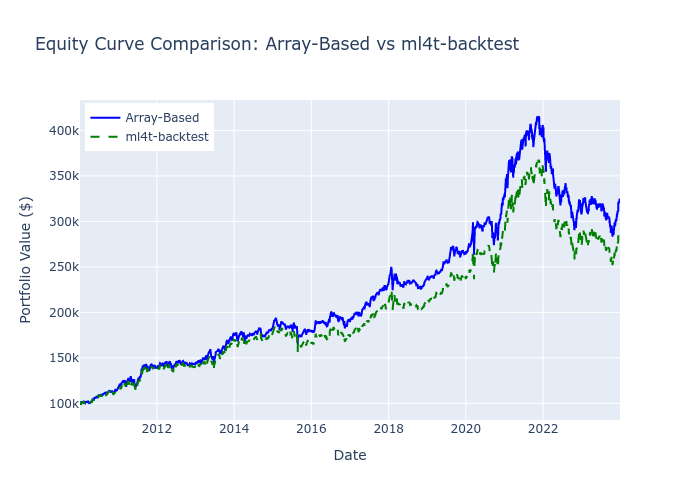

In [16]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=equity_vbt.index,
        y=equity_vbt,
        name="Array-Based",
        line=dict(color="blue", width=2),
    )
)

fig.add_trace(
    go.Scatter(
        x=equity_ml4t.index,
        y=equity_ml4t,
        name="ml4t-backtest",
        line=dict(color="green", width=2, dash="dash"),
    )
)

fig.update_layout(
    title="Equity Curve Comparison: Array-Based vs ml4t-backtest",
    xaxis_title="Date",
    yaxis_title="Portfolio Value ($)",
    height=500,
    legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01),
)
fig.show()

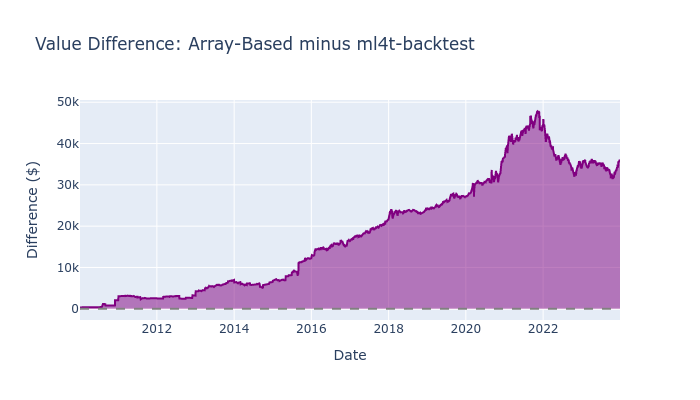

In [17]:
# Difference over time (align index types)
eq_vbt_dt = equity_vbt.copy()
eq_ml4t_dt = equity_ml4t.copy()
eq_vbt_dt.index = pd.to_datetime(eq_vbt_dt.index)
eq_ml4t_dt.index = pd.to_datetime(eq_ml4t_dt.index)
shared_eq = eq_vbt_dt.index.intersection(eq_ml4t_dt.index)
diff_series = eq_vbt_dt.loc[shared_eq] - eq_ml4t_dt.loc[shared_eq]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=diff_series.index,
        y=diff_series,
        name="Array - ml4t",
        fill="tozeroy",
        line=dict(color="purple"),
    )
)

fig.add_hline(y=0, line_dash="dash", line_color="gray")

fig.update_layout(
    title="Value Difference: Array-Based minus ml4t-backtest",
    xaxis_title="Date",
    yaxis_title="Difference ($)",
    height=400,
)
fig.show()

## 8. Sources of Differences

| Aspect | Array-Based Path | Sequential Path |
|---|---|---|
| Execution Timing | Lagged close-to-close | Next-bar execution |
| Cost Model | Turnover $\times$ fee | Per-trade commission |
| Position Tracking | Weight approximation | Shares + cash |
| Cash Management | Implicit | Explicit cash tracking |
| Rebalance Trigger | Any weight change | Strategy callback |

These differences arise from the specific protocol choices used in this
notebook, not from "vectorized versus event-driven" as abstract categories.
The divergence mainly reflects close-to-close returns versus next-bar
execution, turnover-based costs versus per-trade costs, and implicit weights
versus explicit shares and cash. Aligning these assumptions more closely
would shrink the parity gap.

## 9. Correlation of Returns

In [18]:
# Align returns (normalize index types — array path uses date, Engine uses datetime)
vbt_ret = portfolio_returns_vbt_net.copy()
ml4t_ret = portfolio_returns_ml4t.copy()
vbt_ret.index = pd.to_datetime(vbt_ret.index)
ml4t_ret.index = pd.to_datetime(ml4t_ret.index)
common_idx = vbt_ret.index.intersection(ml4t_ret.index)
vbt_aligned = vbt_ret.loc[common_idx].dropna()
ml4t_aligned = ml4t_ret.loc[common_idx].dropna()

# Align again after dropna
shared = vbt_aligned.index.intersection(ml4t_aligned.index)
correlation = np.corrcoef(vbt_aligned.loc[shared], ml4t_aligned.loc[shared])[0, 1]

print("\n" + "=" * 80)
print("RETURN CORRELATION")
print("=" * 80)
print(f"  Correlation: {correlation:.6f}")
print(
    f"  Status: {'EXCELLENT (>0.99)' if correlation > 0.99 else 'GOOD (>0.95)' if correlation > 0.95 else 'REVIEW'}"
)


RETURN CORRELATION
  Correlation: 0.996375
  Status: EXCELLENT (>0.99)


**Interpretation**: A daily-return correlation above 0.99 confirms that both
implementations track the same signal. The remaining gap is almost entirely
explained by timing and cost mechanics, not by divergent trading logic.

## 10. Framework Selection Guide

| Research Need | Convenient First Representation | Why |
|---------------|--------------------------------|-----|
| Parameter sweeps (100+ combos) | Array-based | Fast broadcasting over grids |
| Signal screening | Array-based | Rapid hypothesis filtering |
| Single-protocol parity audit | Either, but align assumptions first | The protocol matters more than the library label |
| Complex order logic | Sequential | Stops, contingencies, and state updates are explicit |
| Short selling / margin | Sequential | Accounting and constraints stay visible |
| Final validation | The implementation that matches the intended execution protocol | No framework wins by default |

For this ETF momentum strategy, both styles can be made comparable once
execution timing and frictions are aligned. The main lesson is to define the
trading protocol first, then choose the implementation style that makes that
protocol easiest to compute and audit.

## Key Takeaways

1. **This notebook compares two implementations of the same strategy**, not
   two immutable categories of truth.

2. **Divergence here reflects timing, cost, and cash-handling choices in this
   notebook**. Audit the protocol before inferring a library limitation.

3. **Consistent metrics matter**: Using `PortfolioAnalysis` for both paths
   ensures Sharpe, drawdown, and other metrics are computed identically.

4. **Array-based research code is attractive when the protocol can be
   precomputed and speed matters**. Sequential simulation is attractive when
   state, order handling, or broker accounting are central to the question.

5. **Do not treat the sequential result as automatically correct**. Trust the
   implementation that best matches the execution protocol you intend to test.

**Next**: `09_performance_reporting` for the full core metric set and tearsheet.
**Book**: Section 16.3 covers the speed-fidelity spectrum in depth.